In [1]:
import sys
import warnings
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np

warnings.filterwarnings("ignore", message="Sortedness of columns cannot be checked.*")

project_root = Path.cwd()
while not (project_root / "requirements.txt").exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.append(str(project_root))

from scipy.stats import norm
from tests.fixtures.synthetic_data import synthetic_actual_df, synthetic_previous_df

from data.fetcher import (
    fetch_data,
    call_fetcher_functions,
    fetch_polymarket_data,
    fetch_polymarket_price_history,
    fetch_all_price_history,
    build_polymarket_price_dataset,
    get_spread_polymarket,
)
from data.cleaner import clean_data, clean_polymarket_data
from data.loader import (
    add_event_column,
    filter_summer,
    get_separate_summer_months,
    add_market_prob_column,
    filter_resolved,
)

from models.baseline import gaussian_probability
from models.kde_model import kde_estimate
from models.bayesian_model import posterior_probability

from pricing.fair_value import (
    get_daily_bucket,
    build_probability_vector,
    build_daily_probability_vector,
    create_buckets,
)
from pricing.edge import prob_market_v_model, effective_edge

from backtest.engine import engine
from evaluation.eval_loop import (
    run_eval_loop_polymarket,
    make_static_factory,
    bayes_static_factory,
)
from risk.metrics import value_at_risk, expected_shortfall, rolling_max_dd

from config.settings import (
    HISTORICAL_START,
    HISTORICAL_END,
    DEFAULT_CITY,
    TOMMORROWS_DATE,
    FORECAST_START,
    FORECAST_END,
    LOWER_BOUND,
    UPPER_BOUND,
    IS_START,
    IS_END,
    OOS_START,
    OOS_END,
)

In [2]:
df_raw = fetch_data(IS_START, IS_END)
df_clean = clean_data(df_raw)
df_event = add_event_column(df_clean)
df_temp_summer = filter_summer(df_event)
df_summer = df_temp_summer["temperature_2m_max"].to_list()

df_pair = call_fetcher_functions(OOS_START, OOS_END)

df_result = build_polymarket_price_dataset()
print(df_result)
lst_buckets = get_daily_bucket(df_result)
lst_days = df_result["date"].to_list()

gaussian_prob_fn = lambda low, high: gaussian_probability(df_summer, low, high)[0]
kde_prob_fn = lambda low, high: kde_estimate(df_summer, low, high)
bayesian_prob_fn = lambda day, low, high: posterior_probability(df_summer, day, df_pair, low, high)

p_gauss = build_probability_vector(gaussian_prob_fn, lst_buckets)
p_kde = build_probability_vector(kde_prob_fn, lst_buckets)
p_bayes = build_daily_probability_vector(bayesian_prob_fn, lst_buckets, lst_days)

edge_gauss = prob_market_v_model(p_gauss, df_result)
edge_kde = prob_market_v_model(p_kde, df_result)
edge_bayes = prob_market_v_model(p_bayes, df_result)

fetch_polymarket_data done after: 2.832533040999806 seconds
clean_polymarket_data done after: 2.8564827079999304 seconds
filter_resolved done after: 2.8580967080006303 seconds
We are on 50 of 1976, this took 4.81 seconds 
We are on 100 of 1976, this took 7.49 seconds 
We are on 150 of 1976, this took 10.47 seconds 
We are on 200 of 1976, this took 13.18 seconds 
We are on 250 of 1976, this took 16.31 seconds 
We are on 300 of 1976, this took 20.38 seconds 
We are on 350 of 1976, this took 22.56 seconds 
We are on 400 of 1976, this took 24.59 seconds 
We are on 450 of 1976, this took 26.54 seconds 
We are on 500 of 1976, this took 28.13 seconds 
We are on 550 of 1976, this took 29.79 seconds 
We are on 600 of 1976, this took 31.64 seconds 
We are on 650 of 1976, this took 33.6 seconds 
We are on 700 of 1976, this took 35.41 seconds 
We are on 750 of 1976, this took 37.69 seconds 
We are on 800 of 1976, this took 39.52 seconds 
We are on 850 of 1976, this took 41.48 seconds 
We are on 90

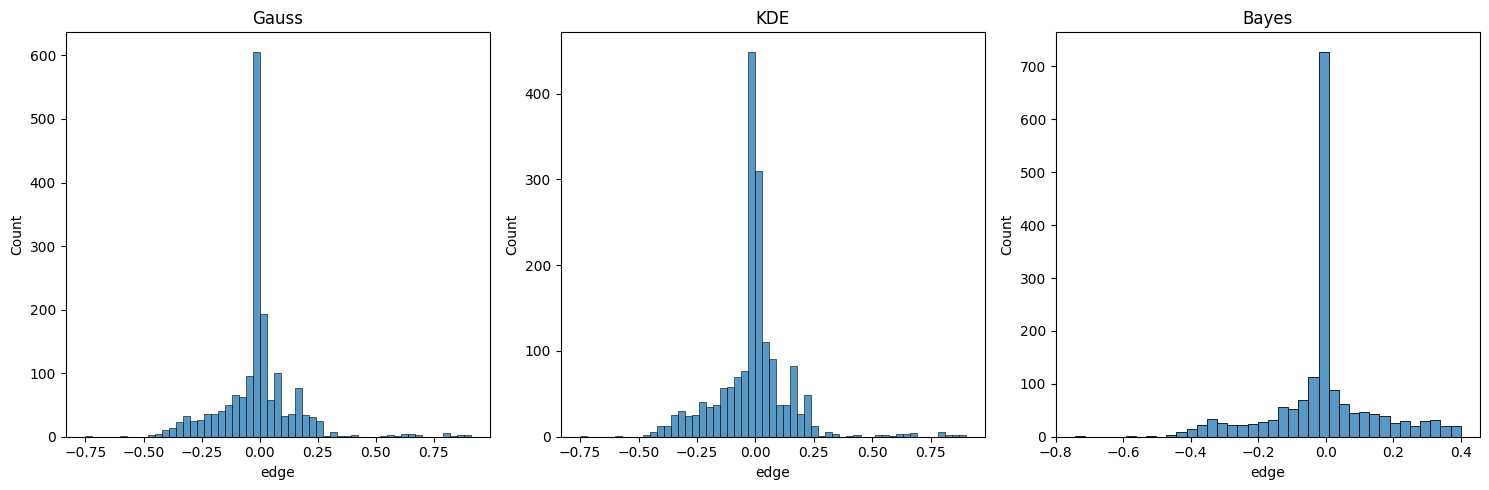

In [3]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(data=edge_gauss["edge"].to_frame(), x ="edge", ax=axes[0],binwidth=0.03)
axes[0].set_title("Gauss")


sns.histplot(data=edge_kde["edge"].to_frame(), x="edge", ax=axes[1],binwidth=0.03)
axes[1].set_title("KDE")


sns.histplot(data=edge_bayes["edge"].to_frame(), x="edge", ax=axes[2],binwidth=0.03)
axes[2].set_title("Bayes")

plt.tight_layout()
plt.show()

Plotted the edge over time, we can see that Gauss and KDE are very similar, almost hard to spot any sudden difference. We can see that all three graphs have their maximum at 0 edge, which means the market's prediction vs the weather prediction are almost the same. We can spot a shift in that Bayes has more bins at the positive edge than Gauss and KDE do.

In [4]:
gauss_factory = make_static_factory(gaussian_prob_fn)
kde_factory = make_static_factory(kde_prob_fn)
bayes_factory = bayes_static_factory(bayesian_prob_fn)

buckets = create_buckets(LOWER_BOUND, UPPER_BOUND)

df_res_gauss = run_eval_loop_polymarket(gauss_factory, buckets, df_pair, df_result)
df_res_kde = run_eval_loop_polymarket(kde_factory, buckets, df_pair, df_result)
df_res_bayes = run_eval_loop_polymarket(bayes_factory, buckets, df_pair, df_result)

gauss_engine = engine(p_gauss, df_res_gauss)
kde_engine = engine(p_kde, df_res_kde)
bayes_engine = engine(p_bayes, df_res_bayes)

print(gauss_engine)
print(kde_engine)
print(bayes_engine)

shape: (663, 28)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬──────────┬───────────┬───────────┐
│ date      ┆ groupItem ┆ groupItem ┆ outcomes  ┆ … ┆ model_sid ┆ stake    ┆ profit    ┆ cumulativ │
│ ---       ┆ Title     ┆ Threshold ┆ ---       ┆   ┆ e         ┆ ---      ┆ ---       ┆ e_profit  │
│ str       ┆ ---       ┆ ---       ┆ list[str] ┆   ┆ ---       ┆ f64      ┆ f64       ┆ ---       │
│           ┆ str       ┆ i64       ┆           ┆   ┆ f64       ┆          ┆           ┆ f64       │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪══════════╪═══════════╪═══════════╡
│ 2026-03-1 ┆ 25°C      ┆ 8         ┆ ["Yes",   ┆ … ┆ 0.994058  ┆ 0.246839 ┆ 0.214517  ┆ 0.214517  │
│ 8         ┆           ┆           ┆ "No"]     ┆   ┆           ┆          ┆           ┆           │
│ 2026-03-1 ┆ 26°C      ┆ 9         ┆ ["Yes",   ┆ … ┆ 0.971611  ┆ 0.224652 ┆ -0.224652 ┆ -0.010135 │
│ 8         ┆           ┆           ┆ "No"]     ┆   ┆           ┆         

In [5]:
vr_gauss = value_at_risk(gauss_engine)
vr_kde = value_at_risk(kde_engine)
vr_bayes = value_at_risk(bayes_engine)

es_gauss = expected_shortfall(gauss_engine, vr_gauss)
es_kde = expected_shortfall(kde_engine, vr_kde)
es_bayes = expected_shortfall(bayes_engine, vr_bayes)

rm_gauss = rolling_max_dd(gauss_engine)
rm_kde = rolling_max_dd(kde_engine)
rm_bayes = rolling_max_dd(bayes_engine)

print(vr_gauss)
print(vr_kde)
print(vr_bayes)

print(es_gauss)
print(es_kde)
print(es_bayes)

print(rm_gauss)
print(rm_kde)
print(rm_bayes)

0.1677124840728685
0.16639626262130036
0.09846072895871469
0.21856177110347835
0.2151122191983879
0.1566297416861203
shape: (663, 29)
┌───────────┬───────────┬───────────┬───────────┬───┬──────────┬───────────┬───────────┬───────────┐
│ date      ┆ groupItem ┆ groupItem ┆ outcomes  ┆ … ┆ stake    ┆ profit    ┆ cumulativ ┆ rolling_m │
│ ---       ┆ Title     ┆ Threshold ┆ ---       ┆   ┆ ---      ┆ ---       ┆ e_profit  ┆ ax        │
│ str       ┆ ---       ┆ ---       ┆ list[str] ┆   ┆ f64      ┆ f64       ┆ ---       ┆ ---       │
│           ┆ str       ┆ i64       ┆           ┆   ┆          ┆           ┆ f64       ┆ f64       │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪══════════╪═══════════╪═══════════╪═══════════╡
│ 2026-03-1 ┆ 25°C      ┆ 8         ┆ ["Yes",   ┆ … ┆ 0.246839 ┆ 0.214517  ┆ 0.214517  ┆ 0.0       │
│ 8         ┆           ┆           ┆ "No"]     ┆   ┆          ┆           ┆           ┆           │
│ 2026-03-1 ┆ 26°C      ┆ 9         ┆ ["Yes",   ┆ … ┆ 0.22